In [15]:
# Project root — edit for your environment.
PROJ_ROOT = "/tscc/projects/ps-renlab2/jhc103/degu-genome-assembly-proj"


# Gene expression violin plots — eight genes of interest (Fig 7D)

Violin plots of expression (TPM) for the eight genes/paralogs of interest
(**Gbp1, Gbp5, Gbp6, Ifng, Casp1, Ccl3, Lgals9, Syncrip**; Cellular Response to Type II Interferon) across 29 RNA-seq samples grouped by tissue.

## Inputs (from the new merged annotation)
- `paralog_families_counts.tsv` — featureCounts gene-level counts over the
  paralog GFF (rows = `gene_id`, cols = `SRR*` samples)
- `paralog_families.tsv` — paralog family metadata (`gene_name`, `gene_id`,
  `gene_type`, `length`, ...)

Both are derived from the new merged AGAT annotation
`hifiasm-041425-denovoEnhanced_peaks2utr_sorted.agat.gff3` (gene IDs `ID=gene-...`).


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [17]:
# ---------------------------------------------------------------------------
# Load expression data (new merged annotation)
# ---------------------------------------------------------------------------
COUNTS_PATH = "merged_paralog_singlecopy_counts.tsv"  # paralog + 3 single-copy interferon genes
FAMILIES_PATH = "merged_paralog_singlecopy_families.tsv"  # paralog + 3 single-copy interferon genes

# featureCounts gene-level counts (index = Geneid = gene_id `ID`)
counts_df = pd.read_csv(COUNTS_PATH, sep='\t', comment='#', index_col=0)
sample_cols = [c for c in counts_df.columns if c.startswith('SRR')]

# paralog family metadata: family, gene_name, gene_id, gene_type, length, ...
families_df = pd.read_csv(FAMILIES_PATH, sep='\t')
print(f'counts: {counts_df.shape[0]} genes x {len(sample_cols)} samples')
print(f'families: {families_df.shape[0]} rows')


counts: 3275 genes x 29 samples
families: 3275 rows


In [18]:
# ---------------------------------------------------------------------------
# Build long-format plot_df with TPM (gene-level, from featureCounts counts)
# ---------------------------------------------------------------------------
meta = families_df[['gene_id', 'gene_name', 'length']].drop_duplicates().set_index('gene_id')

# Melt counts to long format: gene_id, Sample, count
plot_df = counts_df[sample_cols].reset_index().melt(
    id_vars='Geneid', var_name='Sample', value_name='count')
plot_df = plot_df.rename(columns={'Geneid': 'gene_id'})

# TPM normalization (gene-length corrected, per sample)
plot_df['length'] = plot_df['gene_id'].map(meta['length'])
plot_df['RPK'] = plot_df['count'] / (plot_df['length'] / 1000.0)
plot_df['TPM'] = plot_df['RPK'] / plot_df.groupby('Sample')['RPK'].transform('sum') * 1e6

# Map gene_id -> gene_name (Gbp1, Gbp5, Gbp6, Ifng, ...) for filtering/plotting
plot_df['Gene'] = plot_df['gene_id'].map(meta['gene_name'])
plot_df = plot_df.dropna(subset=['Gene'])
plot_df.head()


,gene_id,Sample,count,length,RPK,TPM,Gene
0,gene-Aadac,SRR17216293_Aligned.sortedByCoord.out.bam,14,20944,0.668449,0.585062,Aadac
1,gene-Aadac-l1,SRR17216293_Aligned.sortedByCoord.out.bam,1053,18517,56.866663,49.772710,Aadac-l1
2,gene-Aadac-l2,SRR17216293_Aligned.sortedByCoord.out.bam,854,13583,62.872709,55.029518,Aadac-l2
3,gene-Aadac-l3,SRR17216293_Aligned.sortedByCoord.out.bam,104,12941,8.036473,7.033946,Aadac-l3
4,gene-Aadacl4,SRR17216293_Aligned.sortedByCoord.out.bam,190,24069,7.893971,6.909221,Aadacl4


In [19]:
# ---------------------------------------------------------------------------
# Sample -> tissue + palette (29 SRR samples, 6 tissues)
# ---------------------------------------------------------------------------
sample_to_tissue = {
    'SRR17216293': 'skin', 'SRR17216294': 'brain', 'SRR17216295': 'heart',
    'SRR17216296': 'kidney', 'SRR17216297': 'liver', 'SRR17216298': 'lung',
    'SRR17216299': 'skin', 'SRR17216300': 'brain', 'SRR17216301': 'heart',
    'SRR17216302': 'kidney', 'SRR17216303': 'liver', 'SRR17216304': 'lung',
    'SRR17216305': 'skin', 'SRR17216306': 'brain', 'SRR17216307': 'heart',
    'SRR17216308': 'kidney', 'SRR17216309': 'liver', 'SRR17216310': 'lung',
    'SRR17216311': 'brain', 'SRR17216312': 'heart', 'SRR17216313': 'kidney',
    'SRR17216314': 'kidney', 'SRR17216315': 'lung', 'SRR17216316': 'skin',
    'SRR17216317': 'heart', 'SRR17216318': 'kidney', 'SRR17216319': 'liver',
    'SRR17216320': 'brain', 'SRR17216321': 'lung'
}
tissue_palette = {
    'brain': '#1f77b4', 'heart': '#d62728', 'kidney': '#2ca02c',
    'liver': '#ff7f0e', 'lung': '#9467bd', 'skin': '#e377c2'
}

# featureCounts sample names carry the bam suffix — strip it, then map
plot_df['Sample'] = plot_df['Sample'].str.replace('_Aligned.sortedByCoord.out.bam', '', regex=False)
plot_df['Tissue'] = plot_df['Sample'].map(sample_to_tissue)
plot_df.head()


,gene_id,Sample,count,length,RPK,TPM,Gene,Tissue
0,gene-Aadac,SRR17216293,14,20944,0.668449,0.585062,Aadac,skin
1,gene-Aadac-l1,SRR17216293,1053,18517,56.866663,49.772710,Aadac-l1,skin
2,gene-Aadac-l2,SRR17216293,854,13583,62.872709,55.029518,Aadac-l2,skin
3,gene-Aadac-l3,SRR17216293,104,12941,8.036473,7.033946,Aadac-l3,skin
4,gene-Aadacl4,SRR17216293,190,24069,7.893971,6.909221,Aadacl4,skin


/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_841014/2361576110.py:29: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  plot_df["Gene"].str.contains(
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_841014/2361576110.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_841014/2361576110.py:99: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tscc/lustre/ddn/scratch/jhc103/temp-dir-fast/ipykernel_841014/2361576110.py:99: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=F

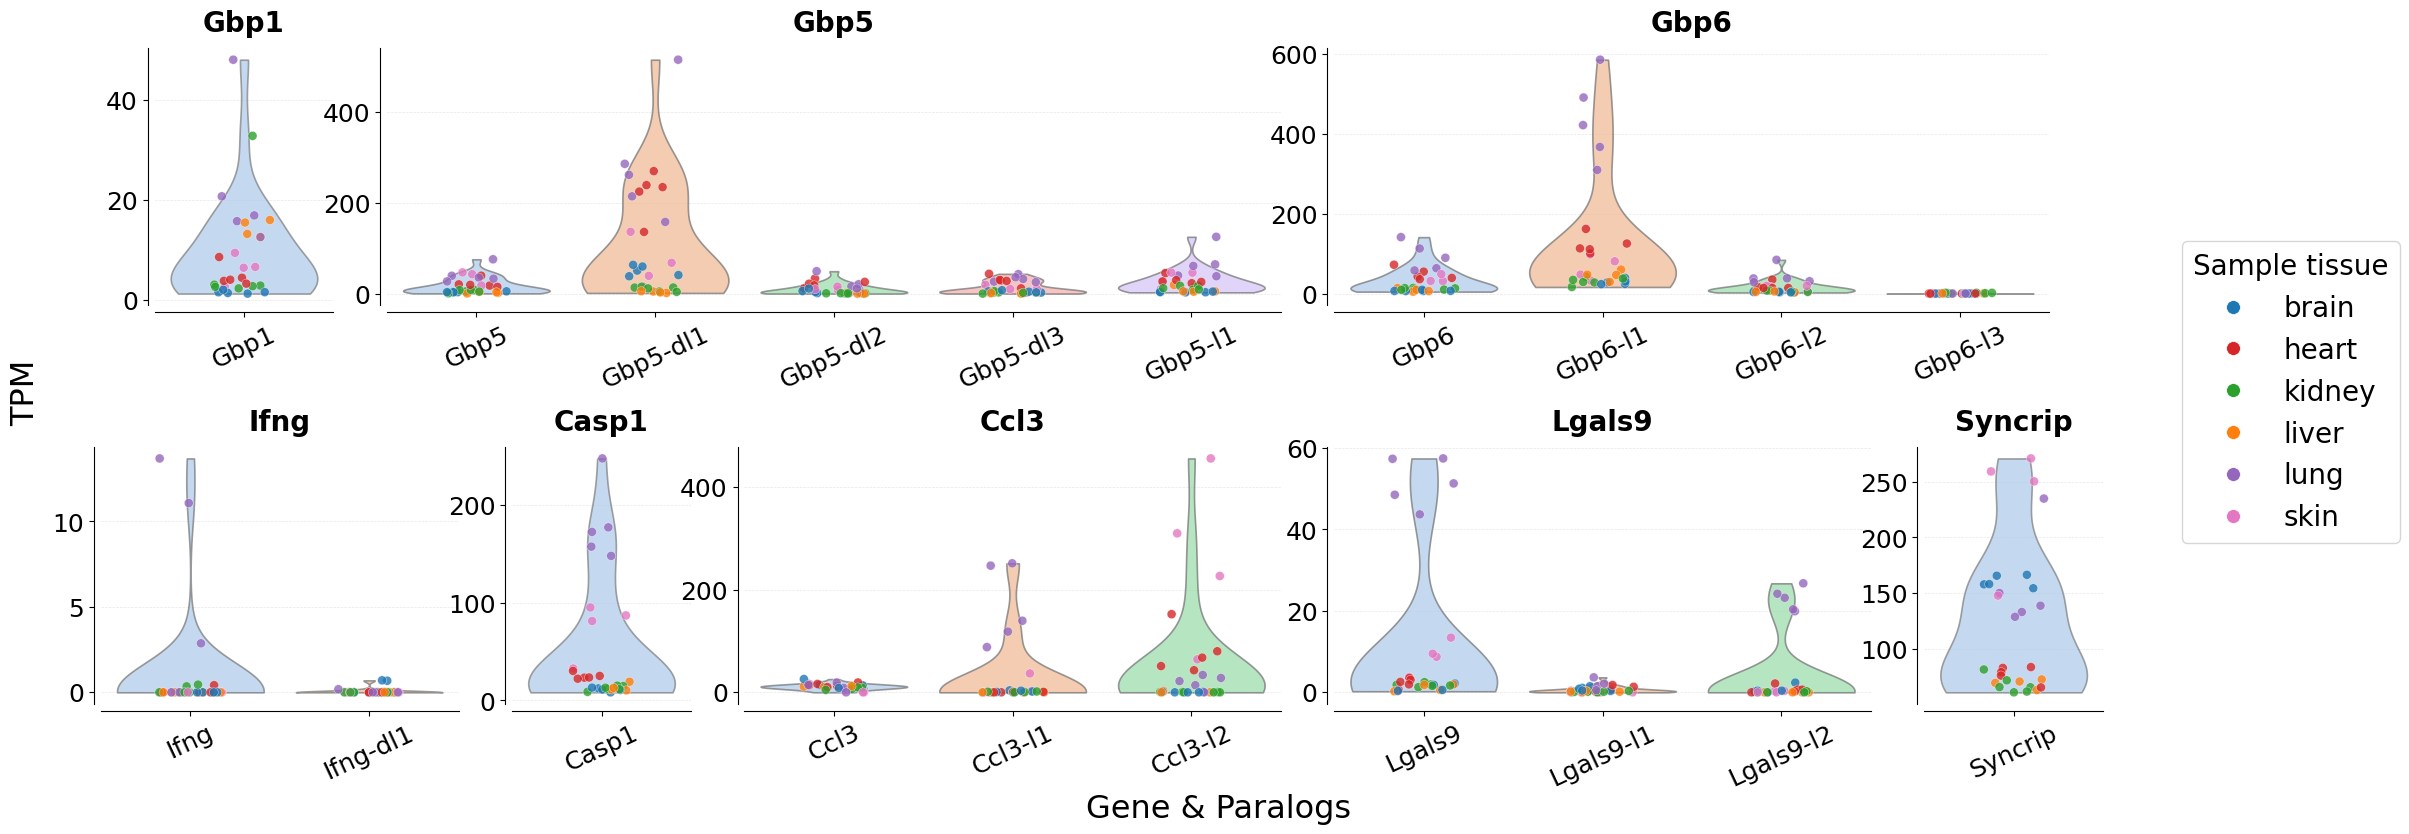

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

size = 20


# The eight genes/paralogs of interest
goi_list = [
    "Gbp1", "Gbp5", "Gbp6", "Ifng",
    "Casp1", "Ccl3", "Lgals9", "Syncrip"
]

# Explicit row organization
plot_rows = [
    goi_list[:3],
    goi_list[3:]
]

# ------------------------------------------------------------
# Prepare the data and determine how many violin slots each
# gene family needs.
# ------------------------------------------------------------
panel_data = {}
panel_widths = {}

for goi in goi_list:
    current_df = plot_df[
        plot_df["Gene"].str.contains(
            rf"^{goi}(-.*)?$",
            regex=True,
            na=False
        )
    ].copy()

    gene_order = sorted(current_df["Gene"].dropna().unique())

    panel_data[goi] = current_df
    panel_widths[goi] = max(len(gene_order), 1)

# ------------------------------------------------------------
# Construct a fine-resolution GridSpec.
#
# Panel width is proportional to the number of gene/paralog
# categories, so each violin occupies approximately the same
# physical width.
# ------------------------------------------------------------
slot_units = 10
gap_units = 3

row_width_units = []

for row in plot_rows:
    width = (
        sum(panel_widths[goi] * slot_units for goi in row)
        + gap_units * (len(row) - 1)
    )
    row_width_units.append(width)

max_width_units = max(row_width_units)

fig = plt.figure(figsize=(26, 8))

grid = fig.add_gridspec(
    nrows=2,
    ncols=max_width_units,
    height_ratios=[1, 1],
    hspace=0.55,
    wspace=0
)

axes = []

# ------------------------------------------------------------
# Draw each row, centered as a complete block
# ------------------------------------------------------------
for row_index, row in enumerate(plot_rows):

    current_row_width = row_width_units[row_index]

    # Center the entire row within the maximum available width
    starting_column = (max_width_units - current_row_width) // 2
    current_column = starting_column

    for goi in row:
        final_plot_df = panel_data[goi]
        gene_order = sorted(final_plot_df["Gene"].dropna().unique())

        panel_units = panel_widths[goi] * slot_units

        ax = fig.add_subplot(
            grid[
                row_index,
                current_column:current_column + panel_units
            ]
        )
        axes.append(ax)

        sns.violinplot(
            data=final_plot_df,
            x="Gene",
            y="TPM",
            order=gene_order,
            ax=ax,
            palette="pastel",
            inner=None,
            scale="width",
            width=0.82,
            cut=0,
            linewidth=1.2
        )

        # Set violin transparency consistently
        for collection in ax.collections:
            if hasattr(collection, "set_alpha"):
                collection.set_alpha(0.7)

        sns.stripplot(
            data=final_plot_df,
            x="Gene",
            y="TPM",
            hue="Tissue",
            order=gene_order,
            ax=ax,
            palette=tissue_palette,
            size=6.5,
            jitter=0.18,
            alpha=0.8,
            edgecolor="white",
            linewidth=0.3
        )

        # Completely remove Seaborn's individual axis labels
        ax.set_xlabel(None)
        ax.set_ylabel(None)
        ax.xaxis.label.set_visible(False)
        ax.yaxis.label.set_visible(False)

        ax.set_title(
            goi,
            fontsize=size,
            fontweight="bold",
            pad=12
        )

        ax.tick_params(
            axis="x",
            rotation=25,
            labelsize=size - 2
        )
        ax.tick_params(
            axis="y",
            labelsize=size - 2
        )

        # Align rotated labels consistently
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")
            label.set_rotation_mode("anchor")

        sns.despine(
            top=True,
            right=True,
            offset=5,
            trim=False,
            ax=ax
        )

        ax.grid(
            axis="y",
            alpha=0.3,
            linestyle="--",
            linewidth=0.5
        )
        ax.set_axisbelow(True)

        # Remove panel-specific legends
        panel_legend = ax.get_legend()
        if panel_legend is not None:
            panel_legend.remove()

        current_column += panel_units + gap_units

# ------------------------------------------------------------
# Shared axis labels
# ------------------------------------------------------------
fig.supylabel(
    "TPM",
    fontsize=size+3,
    x=0.035
)

fig.supxlabel(
    "Gene & Paralogs",
    fontsize=size+3,
    y=-0.04
)

# ------------------------------------------------------------
# Build one clean tissue legend directly from tissue_palette
# ------------------------------------------------------------
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.5,
        markersize=10,
        label=tissue
    )
    for tissue, color in tissue_palette.items()
]

fig.legend(
    handles=legend_handles,
    title="Sample tissue",
    title_fontsize=size,
    fontsize=size,
    loc="center left",
    bbox_to_anchor=(0.865, 0.5),
    ncol=1,
    frameon=True,
    fancybox=True,
    shadow=False
)

# Reserve room for shared labels and the legend
fig.subplots_adjust(
    left=0.07,
    right=0.84,
    bottom=0.11,
    top=0.93
)

plt.show()

In [42]:
# Save figure
fig.savefig("four_genes_expression_violin.png", dpi=300, bbox_inches="tight")
